01. Import Libary

In [1030]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
# Bagian ini memuat seluruh library yang digunakan dalam model UC,
# post-processing, dan simulasi frekuensi.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyomo.environ import (
    ConcreteModel, Set, Param, Var,
    Constraint, Objective,
    NonNegativeReals, Binary,
    SolverFactory, minimize, value
)

from pyomo.opt import SolverStatus, TerminationCondition

2. Konfigurasi Skenario

In [1031]:
# ============================================================
# 2. SCENARIO CONFIGURATION
# ============================================================
# Bagian ini mengatur skenario simulasi.
# use_pfr = True  -> model UC mempertimbangkan alokasi PFR
# use_pfr = False -> model UC berjalan tanpa constraint PFR

use_pfr = False

# Parameter frekuensi sistem
f0 = 50.0          # frekuensi nominal sistem (Hz)
f_min = 49.5       # batas minimum frekuensi yang diizinkan (Hz)
df_max = f0 - f_min

# Parameter simulasi frekuensi post-solve
D_frac = 0.01      # damping beban, 1% load per Hz
sim_time = 200     # durasi simulasi frekuensi (detik)
dt = 0.02          # time step simulasi (detik)

# Jam studi untuk simulasi frekuensi
t_uc = 8

3. Read Data Excel

In [1032]:
# ============================================================
# 3. READ DATA FROM EXCEL
# ============================================================
# Bagian ini membaca data generator dan demand dari file Excel.

file_path = r"D:\UGM\Tugas Akhir\UC Coding\Belajar\DataSet_ModifikasiCandra_R00.xlsx"

gen_df = pd.read_excel(file_path, sheet_name="Gen")
demand_df = pd.read_excel(file_path, sheet_name="Demand")

# Cek cepat isi data
# print(gen_df.head())
# print(demand_df.head())

4. Validasi Kolom Data

In [1033]:
# ============================================================
# 4. DATA VALIDATION
# ============================================================
# Bagian ini memastikan semua kolom wajib tersedia.
# Tujuannya agar error lebih mudah dilacak sebelum masuk ke Pyomo.

required_gen_cols = [
    "Unit", "Pmin", "Pmax", "a", "b", "c",
    "SU_Cost", "SD_Cost",
    "Ramp_Up", "Ramp_Down",
    "Min_Up", "Min_Down",
    "Droop", "PFR_Fraction", "FreeGovernor",
    "Type", "H", "Tg"
]

required_demand_cols = [
    "Hour", "Demand", "Potensi PV (MW)", "Potensi WT (MW)"
]

missing_gen_cols = [col for col in required_gen_cols if col not in gen_df.columns]
missing_demand_cols = [col for col in required_demand_cols if col not in demand_df.columns]

if missing_gen_cols:
    raise ValueError(f"Kolom hilang pada sheet Gen: {missing_gen_cols}")

if missing_demand_cols:
    raise ValueError(f"Kolom hilang pada sheet Demand: {missing_demand_cols}")

5. Konversi DataFrame ke Dictionary

In [1034]:
# ============================================================
# 5. CONVERT DATAFRAME TO DICTIONARY
# ============================================================
# Bagian ini mengubah data pandas menjadi dictionary agar mudah
# digunakan sebagai Pyomo Param.

G = gen_df["Unit"].tolist()
T = demand_df["Hour"].tolist()

# Parameter generator
Pmin = dict(zip(gen_df["Unit"], gen_df["Pmin"]))
Pmax = dict(zip(gen_df["Unit"], gen_df["Pmax"]))

a = dict(zip(gen_df["Unit"], gen_df["a"]))
b = dict(zip(gen_df["Unit"], gen_df["b"]))
c = dict(zip(gen_df["Unit"], gen_df["c"]))

SU_cost = dict(zip(gen_df["Unit"], gen_df["SU_Cost"]))
SD_cost = dict(zip(gen_df["Unit"], gen_df["SD_Cost"]))

RampUp = dict(zip(gen_df["Unit"], gen_df["Ramp_Up"]))
RampDown = dict(zip(gen_df["Unit"], gen_df["Ramp_Down"]))

MinUp = dict(zip(gen_df["Unit"], gen_df["Min_Up"]))
MinDown = dict(zip(gen_df["Unit"], gen_df["Min_Down"]))

Droop = dict(zip(gen_df["Unit"], gen_df["Droop"]))
PFR_Fraction = dict(zip(gen_df["Unit"], gen_df["PFR_Fraction"]))
FreeGovernor = dict(zip(gen_df["Unit"], gen_df["FreeGovernor"]))

Type = dict(zip(gen_df["Unit"], gen_df["Type"]))
H = dict(zip(gen_df["Unit"], gen_df["H"]))
Tg = dict(zip(gen_df["Unit"], gen_df["Tg"]))

# Parameter demand
Demand = dict(zip(demand_df["Hour"], demand_df["Demand"]))

PV_Potential = dict(zip(demand_df["Hour"], demand_df["Potensi PV (MW)"]))
WT_Potential = dict(zip(demand_df["Hour"], demand_df["Potensi WT (MW)"]))

6. Parameter Turunan

In [1035]:
# ============================================================
# 6. DERIVED PARAMETERS
# ============================================================
# Bagian ini menghitung parameter turunan sebelum masuk model Pyomo.

# Potensi renewable per unit dan waktu
RenewPotential = {}

for g in G:
    for t in T:
        if Type[g] == "PV":
            RenewPotential[g, t] = PV_Potential[t]
        elif Type[g] == "WT":
            RenewPotential[g, t] = WT_Potential[t]
        else:
            RenewPotential[g, t] = Pmax[g]

# Batas maksimum PFR tiap unit
PFR_Max = {
    g: PFR_Fraction[g] * Pmax[g]
    for g in G
}

# Frequency bias tiap generator
# Satuan: MW/Hz
FreqBias = {}

for g in G:
    if Droop[g] > 0 and FreeGovernor[g] == 1:
        FreqBias[g] = Pmax[g] / (Droop[g] * f0)
    else:
        FreqBias[g] = 0

# Biaya reserve sederhana
ReserveCost = {
    g: 0.10 * b[g]
    for g in G
}

7. Definisi Model dan Set

In [1036]:
# ============================================================
# 7. MODEL AND SETS
# ============================================================
# Bagian ini membuat model Pyomo dan mendefinisikan set generator serta waktu.

model = ConcreteModel()

model.G = Set(initialize=G)
model.T = Set(initialize=T)

8. Parameter Pyomo

In [1037]:
# ============================================================
# 8. PYOMO PARAMETERS
# ============================================================
# Bagian ini memasukkan parameter numerik ke dalam model Pyomo.

model.Pmin = Param(model.G, initialize=Pmin)
model.Pmax = Param(model.G, initialize=Pmax)

model.a = Param(model.G, initialize=a)
model.b = Param(model.G, initialize=b)
model.c = Param(model.G, initialize=c)

model.SU_cost = Param(model.G, initialize=SU_cost)
model.SD_cost = Param(model.G, initialize=SD_cost)

model.RampUp = Param(model.G, initialize=RampUp)
model.RampDown = Param(model.G, initialize=RampDown)

model.MinUp = Param(model.G, initialize=MinUp)
model.MinDown = Param(model.G, initialize=MinDown)

model.Demand = Param(model.T, initialize=Demand)

model.Droop = Param(model.G, initialize=Droop, within=NonNegativeReals)
model.PFR_Fraction = Param(model.G, initialize=PFR_Fraction, within=NonNegativeReals)
model.FreeGovernor = Param(model.G, initialize=FreeGovernor, within=Binary)
model.PFR_Max = Param(model.G, initialize=PFR_Max, within=NonNegativeReals)

model.FreqBias = Param(model.G, initialize=FreqBias)
model.ReserveCost = Param(model.G, initialize=ReserveCost)

model.RenewPotential = Param(model.G, model.T, initialize=RenewPotential, within=NonNegativeReals)

model.H = Param(model.G, initialize=H)
model.Tg = Param(model.G, initialize=Tg)

9. Variabel Keputusan UC

In [1038]:
# ============================================================
# 9. DECISION VARIABLES
# ============================================================
# Bagian ini mendefinisikan variabel keputusan model UC.
# Semua variabel di sini memengaruhi hasil optimasi.

model.P = Var(model.G, model.T, domain=NonNegativeReals)       # output daya unit
model.u = Var(model.G, model.T, domain=Binary)                 # status ON/OFF unit
model.y = Var(model.G, model.T, domain=Binary)                 # startup
model.z = Var(model.G, model.T, domain=Binary)                 # shutdown

model.R = Var(model.G, model.T, within=NonNegativeReals)       # spinning reserve
model.Curt = Var(model.G, model.T, within=NonNegativeReals)    # renewable curtailment

# R_pfr hanya digunakan jika skenario PFR aktif.
model.R_pfr = Var(model.G, model.T, within=NonNegativeReals)   # primary frequency reserve

10. Objective Function

In [1039]:
# ============================================================
# 10. OBJECTIVE FUNCTION
# ============================================================
# Fungsi objektif meminimalkan total biaya operasi:
# fuel cost, fixed cost, startup, shutdown, dan reserve cost.

def obj_rule(m):
    return sum(
        m.b[g] * m.P[g, t]
        + m.c[g] * m.u[g, t]
        + m.SU_cost[g] * m.y[g, t]
        + m.SD_cost[g] * m.z[g, t]
        + m.ReserveCost[g] * m.R[g, t]
        for g in m.G for t in m.T
    )

model.Obj = Objective(rule=obj_rule, sense=minimize)

11. Constraint UC Dasar

In [1040]:
# ============================================================
# 11. BASIC UC CONSTRAINTS
# ============================================================
# Bagian ini berisi constraint utama Unit Commitment.

# ----------------------------
# 11.1 Power Balance
# ----------------------------
# Total pembangkitan harus sama dengan demand setiap jam.

def balance_rule(m, t):
    return sum(m.P[g, t] for g in m.G) == m.Demand[t]

model.Balance = Constraint(model.T, rule=balance_rule)

In [1041]:
# ----------------------------
# 11.2 Capacity Upper Bound
# ----------------------------
# Output unit tidak boleh melebihi kapasitas maksimum saat unit ON.
# Untuk PV dan WT, batasnya mengikuti potensi renewable.

def max_rule(m, g, t):
    if Type[g] in ["PV", "WT"]:
        return m.P[g, t] <= m.RenewPotential[g, t]
    else:
        return m.P[g, t] <= m.Pmax[g] * m.u[g, t]

model.MaxCap = Constraint(model.G, model.T, rule=max_rule)

In [1042]:
# ----------------------------
# 11.3 Capacity Lower Bound
# ----------------------------
# Output thermal unit minimal Pmin saat unit ON.
# PV dan WT tidak dipaksa memiliki Pmin.

def min_rule(m, g, t):
    if Type[g] in ["PV", "WT"]:
        return m.P[g, t] >= 0
    else:
        return m.P[g, t] >= m.Pmin[g] * m.u[g, t]

model.MinCap = Constraint(model.G, model.T, rule=min_rule)

In [1043]:
# ----------------------------
# 11.4 Startup and Shutdown Transition
# ----------------------------
# Menghubungkan perubahan status unit dengan startup dan shutdown.

def transition_rule(m, g, t):
    if t == min(T):
        return m.u[g, t] == m.y[g, t] - m.z[g, t]
    else:
        return m.u[g, t] - m.u[g, t-1] == m.y[g, t] - m.z[g, t]

model.Transition = Constraint(model.G, model.T, rule=transition_rule)

In [1044]:
# ----------------------------
# 11.5 Ramp Up
# ----------------------------
# Membatasi kenaikan daya antar jam.

def ramp_up_rule(m, g, t):
    if t == min(T):
        return Constraint.Skip
    return m.P[g, t] - m.P[g, t-1] <= m.RampUp[g]

model.RampUpConstraint = Constraint(model.G, model.T, rule=ramp_up_rule)

In [1045]:
# ----------------------------
# 11.6 Ramp Down
# ----------------------------
# Membatasi penurunan daya antar jam.

def ramp_down_rule(m, g, t):
    if t == min(T):
        return Constraint.Skip
    return m.P[g, t-1] - m.P[g, t] <= m.RampDown[g]

model.RampDownConstraint = Constraint(model.G, model.T, rule=ramp_down_rule)

In [1046]:
# ----------------------------
# 11.7 Minimum Up Time
# ----------------------------
# Jika unit startup, maka unit harus ON minimal selama MinUp.

def min_up_rule(m, g, t):
    MU = int(value(m.MinUp[g]))
    if t + MU - 1 > max(T):
        return Constraint.Skip
    return sum(m.u[g, k] for k in range(t, t + MU)) >= MU * m.y[g, t]

model.MinUpConstraint = Constraint(model.G, model.T, rule=min_up_rule)

In [1047]:
# ----------------------------
# 11.8 Minimum Down Time
# ----------------------------
# Jika unit shutdown, maka unit harus OFF minimal selama MinDown.

def min_down_rule(m, g, t):
    MD = int(value(m.MinDown[g]))
    if t + MD - 1 > max(T):
        return Constraint.Skip
    return sum(1 - m.u[g, k] for k in range(t, t + MD)) >= MD * m.z[g, t]

model.MinDownConstraint = Constraint(model.G, model.T, rule=min_down_rule)

12. Contraint Reserve dan Renewable

In [1048]:
# ============================================================
# 12. RESERVE AND RENEWABLE CONSTRAINTS
# ============================================================
# Bagian ini mengatur spinning reserve, N-1 reserve, dan curtailment.

# ----------------------------
# 12.1 Reserve Headroom
# ----------------------------
# Reserve hanya boleh berasal dari kapasitas kosong unit thermal.
# PV dan WT tidak menyediakan spinning reserve dalam model ini.

def reserve_cap_rule(m, g, t):
    if Type[g] in ["PV", "WT"]:
        return m.R[g, t] == 0
    else:
        return m.P[g, t] + m.R[g, t] <= m.Pmax[g] * m.u[g, t]

model.ReserveCap = Constraint(model.G, model.T, rule=reserve_cap_rule)

In [1049]:
# ----------------------------
# 12.2 N-1 Reserve Constraint
# ----------------------------
# Reserve dari unit lain harus cukup untuk menutup kehilangan unit thermal terbesar.
# Constraint ini membuat model lebih aman terhadap kontingensi unit terbesar.

def n1_reserve_rule(m, outage_g, t):
    if Type[outage_g] not in ["PV", "WT"]:
        return sum(
            m.R[g, t]
            for g in m.G
            if g != outage_g and Type[g] not in ["PV", "WT"]
        ) >= m.P[outage_g, t]
    else:
        return Constraint.Skip

model.N1Reserve = Constraint(model.G, model.T, rule=n1_reserve_rule)

In [1050]:
# ----------------------------
# 12.3 Renewable Curtailment
# ----------------------------
# Curtailment = potensi renewable - dispatch renewable.

def curtailment_rule(m, g, t):
    if Type[g] in ["PV", "WT"]:
        return m.Curt[g, t] == m.RenewPotential[g, t] - m.P[g, t]
    else:
        return m.Curt[g, t] == 0

model.Curtailment = Constraint(model.G, model.T, rule=curtailment_rule)

13. Constraint PFR/FCUC

In [1051]:
# ============================================================
# 13. PFR CONSTRAINTS
# ============================================================
# Bagian ini hanya aktif jika use_pfr = True.
# PFR di sini masih berupa alokasi reserve, bukan simulasi frekuensi dinamik.

if use_pfr:

    # PFR tidak boleh melebihi headroom unit
    def pfr_headroom_rule(m, g, t):
        return m.R_pfr[g, t] <= m.Pmax[g] * m.u[g, t] - m.P[g, t]

    model.PFR_Headroom = Constraint(model.G, model.T, rule=pfr_headroom_rule)


    # PFR dibatasi kemampuan governor dan status ON unit
    def pfr_cap_rule(m, g, t):
        return m.R_pfr[g, t] <= m.PFR_Max[g] * m.FreeGovernor[g] * m.u[g, t]

    model.PFR_Cap = Constraint(model.G, model.T, rule=pfr_cap_rule)


    # PFR harus merupakan bagian dari spinning reserve
    def pfr_within_reserve_rule(m, g, t):
        return m.R_pfr[g, t] <= m.R[g, t]

    model.PFR_Within_Reserve = Constraint(model.G, model.T, rule=pfr_within_reserve_rule)

else:

    # Jika skenario PFR tidak aktif, R_pfr dipaksa nol.
    def no_pfr_rule(m, g, t):
        return m.R_pfr[g, t] == 0

    model.NoPFR = Constraint(model.G, model.T, rule=no_pfr_rule)

14. Solve Model

In [1052]:
# ============================================================
# 14. SOLVE MODEL
# ============================================================
# Bagian ini menjalankan solver MILP.

solver = SolverFactory("cbc")
results = solver.solve(model, tee=False)

if (
    results.solver.status == SolverStatus.ok
    and results.solver.termination_condition == TerminationCondition.optimal
):
    print("Optimal solution found.")
else:
    print("Model infeasible or not optimal.")
    print(results.solver.status)
    print(results.solver.termination_condition)

Optimal solution found.


15-Build Result DataFrame

In [1053]:
# ============================================================
# 15. BUILD RESULT DATAFRAME
# ============================================================
# Bagian ini mengambil hasil optimasi dari Pyomo dan menyusunnya
# menjadi dataframe agar mudah dibaca, dicetak, dan diplot.

def fmt(x):
    if abs(x - round(x)) < 1e-6:
        return int(round(x))
    return round(x, 2)


rows = []

for t in model.T:
    row = {
        "Hour": t,
        "Demand": fmt(value(model.Demand[t]))
    }

    total_power = 0
    total_reserve = 0
    total_pfr = 0

    fuel_cost = 0
    fixed_cost = 0
    startup_cost = 0
    shutdown_cost = 0
    reserve_cost = 0

    for g in model.G:
        p = value(model.P[g, t])
        u = value(model.u[g, t])
        y = value(model.y[g, t])
        z = value(model.z[g, t])
        r = value(model.R[g, t])
        r_pfr = value(model.R_pfr[g, t])

        row[f"{g}_P"] = fmt(p)
        row[f"{g}_U"] = fmt(u)
        row[f"{g}_Y"] = fmt(y)
        row[f"{g}_Z"] = fmt(z)
        row[f"{g}_R"] = fmt(r)
        row[f"{g}_PFR"] = fmt(r_pfr)
        row[f"{g}_Headroom"] = fmt(value(model.Pmax[g]) * u - p)

        if Type[g] in ["PV", "WT"]:
            row[f"{g}_Curt"] = fmt(value(model.Curt[g, t]))

        total_power += p
        total_reserve += r
        total_pfr += r_pfr

        fuel_cost += p * value(model.b[g])
        fixed_cost += u * value(model.c[g])
        startup_cost += y * value(model.SU_cost[g])
        shutdown_cost += z * value(model.SD_cost[g])
        reserve_cost += r * value(model.ReserveCost[g])

    row["Total_Power"] = fmt(total_power)
    row["Total_Reserve"] = fmt(total_reserve)
    row["Total_PFR"] = fmt(total_pfr)

    row["Contingency"] = fmt(max(
        value(model.P[g, t])
        for g in model.G
        if Type[g] not in ["PV", "WT"]
    ))

    row["Reserve_Margin"] = fmt(row["Total_Reserve"] - row["Contingency"])

    row["Fuel Cost"] = fmt(fuel_cost)
    row["Fixed Cost"] = fmt(fixed_cost)
    row["Startup Cost"] = fmt(startup_cost)
    row["Shutdown Cost"] = fmt(shutdown_cost)
    row["Reserve Cost"] = fmt(reserve_cost)
    row["Total Cost"] = fmt(
        fuel_cost + fixed_cost + startup_cost + shutdown_cost + reserve_cost
    )

    rows.append(row)

df_hourly = pd.DataFrame(rows)

16-Tabel Hasil UC

In [1054]:
# ============================================================
# 16. UC RESULT TABLES
# ============================================================
# Bagian ini menampilkan tabel dispatch, status unit, reserve, biaya,
# ramping, dan ringkasan sistem.

# ----------------------------
# 16.1 Tabel Dispatch
# ----------------------------

print("\n========== TABEL A: DISPATCH ==========")

dispatch_cols = ["Hour", "Demand"] + [f"{g}_P" for g in model.G] + ["Total_Power"]
print(df_hourly[dispatch_cols].to_string(index=False))


========== TABEL A: DISPATCH ==========
 Hour  Demand    G1_P  G2_P   G3_P  G4_P  G5_P   G6_P   G7_P   G8_P  G9_P  G10_P  Total_Power
    1 4225.68  958.91     0 958.91     0     0 250.00   0.00 347.85   870 840.00      4225.68
    2 4173.17  932.66     0 932.66     0     0 250.00   0.00 347.85   870 840.00      4173.17
    3 4089.20  890.68     0 890.68     0     0 250.00   0.00 347.85   870 840.00      4089.20
    4 4009.38  831.53     0 870.00     0     0 250.00   0.00 347.85   870 840.00      4009.38
    5 4009.38  870.00     0 870.00     0     0 250.00   0.00 347.85   870 801.53      4009.38
    6 4211.52  951.84     0 951.84     0     0 250.00   0.00 347.85   870 840.00      4211.52
    7 4273.06  996.21     0 969.00     0     0 250.00   0.00 347.85   870 840.00      4273.06
    8 4224.69 1056.00     0 969.00     0     0 250.00   0.00 347.85   870 731.84      4224.69
    9 4531.45 1176.00     0 969.00     0     0 328.60   0.00 347.85   870 840.00      4531.45
   10 4847.07 1176.

In [1055]:
# ----------------------------
# 16.2 Tabel Status Unit
# ----------------------------

print("\n========== TABEL B: STATUS UNIT ==========")

status_cols = ["Hour"] + [f"{g}_U" for g in model.G]
print(df_hourly[status_cols].to_string(index=False))


========== TABEL B: STATUS UNIT ==========
 Hour  G1_U  G2_U  G3_U  G4_U  G5_U  G6_U  G7_U  G8_U  G9_U  G10_U
    1     1     0     1     0     0     1     0     1     1      1
    2     1     0     1     0     0     1     0     1     1      1
    3     1     0     1     0     0     1     0     1     1      1
    4     1     0     1     0     0     1     0     1     1      1
    5     1     0     1     0     0     1     0     1     1      1
    6     1     0     1     0     0     1     0     1     1      1
    7     1     0     1     0     0     1     0     1     1      1
    8     1     0     1     0     0     1     0     1     1      1
    9     1     0     1     0     0     1     0     1     1      1
   10     1     0     1     0     0     1     1     1     1      1
   11     1     0     1     0     0     1     1     1     1      1
   12     1     0     1     0     0     1     1     1     1      1
   13     1     0     1     0     0     1     1     1     1      1
   14     1     0 

In [1056]:
# ----------------------------
# 16.3 Tabel Reserve
# ----------------------------

print("\n========== TABEL C: RESERVE ==========")

reserve_cols = ["Hour", "Contingency"] + [f"{g}_R" for g in model.G] + [
    "Total_Reserve", "Reserve_Margin"
]
print(df_hourly[reserve_cols].to_string(index=False))


========== TABEL C: RESERVE ==========
 Hour  Contingency  G1_R  G2_R  G3_R  G4_R  G5_R   G6_R   G7_R   G8_R  G9_R  G10_R  Total_Reserve  Reserve_Margin
    1       958.91  0.00     0     0     0     0 708.91   0.00 250.00     0   0.00         958.91               0
    2       932.66  0.00     0     0     0     0 682.66   0.00 250.00     0   0.00         932.66               0
    3       890.68  0.00     0     0     0     0 640.68   0.00 250.00     0   0.00         890.68               0
    4       870.00 38.47     0     0     0     0 620.00   0.00 211.53     0   0.00         870.00               0
    5       870.00  0.00     0     0     0     0 620.00   0.00 211.53     0  38.47         870.00               0
    6       951.84  0.00     0     0     0     0 701.84   0.00 250.00     0   0.00         951.84               0
    7       996.21  0.00     0     0     0     0 746.21   0.00 250.00     0   0.00         996.21               0
    8      1056.00  0.00     0     0     0     0

In [1057]:
# ----------------------------
# 16.4 Tabel Biaya
# ----------------------------

print("\n========== TABEL D: BIAYA ==========")

cost_cols = [
    "Hour", "Fuel Cost", "Fixed Cost",
    "Startup Cost", "Shutdown Cost",
    "Reserve Cost", "Total Cost"
]
print(df_hourly[cost_cols].to_string(index=False))


========== TABEL D: BIAYA ==========
 Hour  Fuel Cost  Fixed Cost  Startup Cost  Shutdown Cost  Reserve Cost  Total Cost
    1  125355.99       20297        342190              0       4919.23   492762.21
    2  123985.52       20297             0              0       4784.54   149067.06
    3  121793.99       20297             0              0       4569.17   146660.15
    4  119710.73       20297             0              0       4366.16   144373.89
    5  119710.73       20297             0              0       4366.16   144373.89
    6  124986.52       20297             0              0       4882.92   150166.43
    7  126592.70       20297             0              0       5110.56   152000.26
    8  125330.28       20297             0              0       5144.72   150772.00
    9  135317.59       20297             0              0       6032.88   161647.47
   10  151508.79       23087         64800              0       6032.88   245428.67
   11  158378.51       23087          

In [1058]:
# ----------------------------
# 16.5 Tabel Ramping
# ----------------------------

print("\n========== TABEL E: RAMPING ==========")

ramp_rows = []

for t in model.T:
    ramp_row = {"Hour": t}

    if t == min(T):
        for g in model.G:
            ramp_row[f"Δ{g}"] = "-"
    else:
        for g in model.G:
            dp = value(model.P[g, t]) - value(model.P[g, t-1])
            ramp_row[f"Δ{g}"] = fmt(dp)

    ramp_rows.append(ramp_row)

df_ramp = pd.DataFrame(ramp_rows)
print(df_ramp.to_string(index=False))


========== TABEL E: RAMPING ==========
 Hour    ΔG1 ΔG2    ΔG3 ΔG4 ΔG5     ΔG6     ΔG7     ΔG8 ΔG9    ΔG10
    1      -   -      -   -   -       -       -       -   -       -
    2 -26.25   0 -26.25   0   0       0       0       0   0       0
    3 -41.98   0 -41.98   0   0       0       0       0   0       0
    4 -59.14   0 -20.68   0   0       0       0       0   0       0
    5  38.47   0      0   0   0       0       0       0   0  -38.47
    6  81.84   0  81.84   0   0       0       0       0   0   38.47
    7  44.37   0  17.16   0   0       0       0       0   0       0
    8  59.79   0      0   0   0       0       0       0   0 -108.16
    9    120   0      0   0   0    78.6       0       0   0  108.16
   10      0   0      0   0   0   -78.6     300   94.22   0       0
   11      0   0      0   0   0     231     -52  -45.09   0       0
   12      0   0      0   0   0    -231     231   51.13   0       0
   13      0   0      0   0   0   80.73    -231 -100.27   0       0
   14   

In [1059]:
# ----------------------------
# 16.6 System Summary
# ----------------------------

print("\n========== TABEL F: SYSTEM SUMMARY ==========")

peak_demand = max(value(model.Demand[t]) for t in model.T)
total_cost_system = value(model.Obj)

total_startup = sum(value(model.y[g, t]) for g in model.G for t in model.T)
total_shutdown = sum(value(model.z[g, t]) for g in model.G for t in model.T)

summary_rows = [
    ["Peak Demand", fmt(peak_demand)],
    ["Total System Cost", fmt(total_cost_system)],
    ["Minimum Reserve Margin", fmt(df_hourly["Reserve_Margin"].min())],
    ["Total Startup Events", fmt(total_startup)],
    ["Total Shutdown Events", fmt(total_shutdown)]
]

df_sys_summary = pd.DataFrame(summary_rows, columns=["Item", "Value"])
print(df_sys_summary.to_string(index=False))


========== TABEL F: SYSTEM SUMMARY ==========
                  Item      Value
           Peak Demand    5132.40
     Total System Cost 4530053.05
Minimum Reserve Margin       0.00
  Total Startup Events       7.00
 Total Shutdown Events       1.00


17-Post-Solve N-1 Check

In [1060]:
# ============================================================
# 17. POST-SOLVE N-1 BACKUP CHECK
# ============================================================
# Bagian ini mengecek apakah reserve dari unit lain cukup untuk
# menutup kehilangan unit thermal terbesar.
# Ini hanya validasi, bukan constraint tambahan.

print("\n========== N-1 LARGEST OUTAGE BACKUP CHECK ==========")

for t in model.T:
    outage_g = max(
        [g for g in model.G if Type[g] not in ["PV", "WT"]],
        key=lambda g: value(model.P[g, t])
    )

    loss = value(model.P[outage_g, t])

    total_backup = sum(
        value(model.R[g, t])
        for g in model.G
        if g != outage_g and Type[g] not in ["PV", "WT"]
    )

    margin = total_backup - loss

    print(f"\nHour {t}")
    print(f"Outage terbesar : {outage_g}")
    print(f"Loss            : {loss:.2f} MW")
    print(f"Total backup    : {total_backup:.2f} MW")
    print(f"Margin          : {margin:.2f} MW")
    print("Status          :", "OK" if margin >= -1e-6 else "FAIL")


========== N-1 LARGEST OUTAGE BACKUP CHECK ==========

Hour 1
Outage terbesar : G1
Loss            : 958.91 MW
Total backup    : 958.91 MW
Margin          : 0.00 MW
Status          : OK

Hour 2
Outage terbesar : G1
Loss            : 932.66 MW
Total backup    : 932.66 MW
Margin          : 0.00 MW
Status          : OK

Hour 3
Outage terbesar : G1
Loss            : 890.68 MW
Total backup    : 890.68 MW
Margin          : 0.00 MW
Status          : OK

Hour 4
Outage terbesar : G3
Loss            : 870.00 MW
Total backup    : 870.00 MW
Margin          : -0.00 MW
Status          : OK

Hour 5
Outage terbesar : G1
Loss            : 870.00 MW
Total backup    : 870.00 MW
Margin          : -0.00 MW
Status          : OK

Hour 6
Outage terbesar : G1
Loss            : 951.84 MW
Total backup    : 951.84 MW
Margin          : 0.00 MW
Status          : OK

Hour 7
Outage terbesar : G1
Loss            : 996.21 MW
Total backup    : 996.21 MW
Margin          : 0.00 MW
Status          : OK

Hour 8
Outage terb

18-Simulasi Frekuensi Post Solve

In [1061]:
# ============================================================
# 18. FREQUENCY RESPONSE SIMULATION
# ============================================================
# Bagian ini melakukan simulasi respons frekuensi SETELAH UC selesai.
# Simulasi ini tidak memengaruhi hasil optimasi UC.

def simulate_frequency_response(model, t_uc, f0=50.0, D_frac=0.01, sim_time=200, dt=0.02):
    """
    Simulasi respons frekuensi akibat trip unit terbesar pada jam tertentu.

    Input:
    - model    : hasil model Pyomo yang sudah solved
    - t_uc     : jam studi
    - f0       : frekuensi nominal
    - D_frac   : load damping fraction
    - sim_time : durasi simulasi
    - dt       : time step

    Output:
    - dictionary berisi time, freq, PFR response, nadir, RoCoF, QSS
    """

    time = np.arange(0, sim_time + dt, dt)

    # Cari unit thermal dengan output terbesar
    outage_g = max(
        [g for g in model.G if Type[g] not in ["PV", "WT"]],
        key=lambda g: value(model.P[g, t_uc])
    )

    loss = value(model.P[outage_g, t_uc])
    demand_t = value(model.Demand[t_uc])

    # Load damping dalam MW/Hz
    D = D_frac * demand_t

    # Inersia sistem setelah unit outage dikeluarkan
    Hsys_MWs = sum(
        value(model.H[g]) * value(model.Pmax[g]) * value(model.u[g, t_uc])
        for g in model.G
        if g != outage_g and Type[g] not in ["PV", "WT"]
    )

    # Unit yang dapat berkontribusi PFR
    pfr_units = [
        g for g in model.G
        if g != outage_g
        and Type[g] not in ["PV", "WT"]
        and value(model.u[g, t_uc]) > 0.5
        and value(model.FreeGovernor[g]) == 1
        and value(model.R[g, t_uc]) > 1e-6
    ]

    df = 0.0
    freq = []

    pfr_response = {g: 0.0 for g in model.G}
    pfr_history = {g: [] for g in pfr_units}
    total_pfr_history = []

    for tau in time:
        total_pfr = 0.0

        for g in pfr_units:
            freq_bias = value(model.FreqBias[g])
            tg = value(model.Tg[g])
            r_cap = value(model.R[g, t_uc])

            # Target PFR berbasis droop
            # Jika frekuensi turun, df bernilai negatif
            target = freq_bias * max(0, -df)

            # PFR tidak boleh melebihi reserve unit
            target = min(target, r_cap)

            # Respons governor orde-1
            pfr_response[g] += (target - pfr_response[g]) * dt / tg

            total_pfr += pfr_response[g]
            pfr_history[g].append(pfr_response[g])

        # Swing equation agregat
        power_imbalance = -loss + total_pfr - D * df

        df_dt = (f0 / (2 * Hsys_MWs)) * power_imbalance
        df += df_dt * dt

        freq.append(f0 + df)
        total_pfr_history.append(total_pfr)

    freq = np.array(freq)
    total_pfr_history = np.array(total_pfr_history)

    nadir = np.min(freq)
    t_nadir = time[np.argmin(freq)]
    qss = freq[-1]

    rocof_series = np.diff(freq) / dt
    rocof_initial = rocof_series[0]
    rocof_min = np.min(rocof_series)

    return {
        "time": time,
        "freq": freq,
        "outage_g": outage_g,
        "loss": loss,
        "demand": demand_t,
        "Hsys_MWs": Hsys_MWs,
        "D": D,
        "pfr_units": pfr_units,
        "pfr_history": pfr_history,
        "total_pfr_history": total_pfr_history,
        "nadir": nadir,
        "t_nadir": t_nadir,
        "qss": qss,
        "rocof_initial": rocof_initial,
        "rocof_min": rocof_min
    }

19-Jalankan Simulasi Frekuensi

In [1062]:
# ============================================================
# 19. RUN FREQUENCY SIMULATION
# ============================================================

freq_result = simulate_frequency_response(
    model=model,
    t_uc=t_uc,
    f0=f0,
    D_frac=D_frac,
    sim_time=sim_time,
    dt=dt
)

print("\n========== HASIL ANALISIS FREKUENSI ==========")
print(f"Hour             : {t_uc}")
print(f"Outage           : {freq_result['outage_g']}")
print(f"Loss             : {freq_result['loss']:.2f} MW")
print(f"Demand           : {freq_result['demand']:.2f} MW")
print(f"Hsys             : {freq_result['Hsys_MWs']:.2f} MW.s")
print(f"Damping          : {freq_result['D']:.2f} MW/Hz")
print(f"PFR units        : {freq_result['pfr_units']}")
print(f"Nadir            : {freq_result['nadir']:.3f} Hz")
print(f"Time of Nadir    : {freq_result['t_nadir']:.2f} s")
print(f"QSS Frequency    : {freq_result['qss']:.3f} Hz")
print(f"Initial RoCoF    : {freq_result['rocof_initial']:.3f} Hz/s")
print(f"Minimum RoCoF    : {freq_result['rocof_min']:.3f} Hz/s")


========== HASIL ANALISIS FREKUENSI ==========
Hour             : 8
Outage           : G1
Loss             : 1056.00 MW
Demand           : 4224.69 MW
Hsys             : 14837.50 MW.s
Damping          : 42.25 MW/Hz
PFR units        : ['G6', 'G8', 'G10']
Nadir            : 47.834 Hz
Time of Nadir    : 3.00 s
QSS Frequency    : 48.322 Hz
Initial RoCoF    : -1.775 Hz/s
Minimum RoCoF    : -1.775 Hz/s


20-Plot Frekuensi

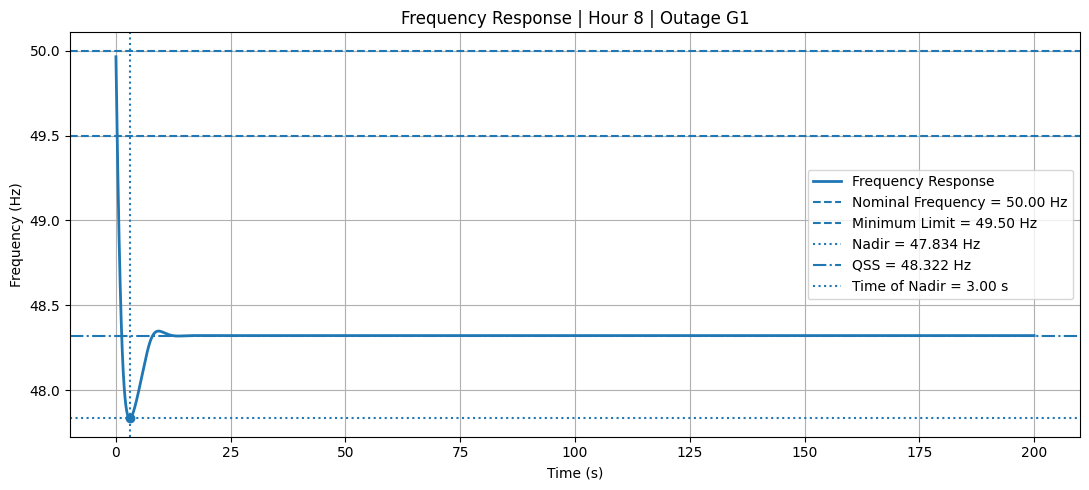

In [1063]:
# ============================================================
# 20. PLOT FREQUENCY RESPONSE
# ============================================================

time = freq_result["time"]
freq = freq_result["freq"]

nadir = freq_result["nadir"]
t_nadir = freq_result["t_nadir"]
qss = freq_result["qss"]

plt.figure(figsize=(11, 5))

plt.plot(time, freq, linewidth=2, label="Frequency Response")

plt.axhline(f0, linestyle="--", label=f"Nominal Frequency = {f0:.2f} Hz")
plt.axhline(f_min, linestyle="--", label=f"Minimum Limit = {f_min:.2f} Hz")
plt.axhline(nadir, linestyle=":", label=f"Nadir = {nadir:.3f} Hz")
plt.axhline(qss, linestyle="-.", label=f"QSS = {qss:.3f} Hz")

plt.axvline(t_nadir, linestyle=":", label=f"Time of Nadir = {t_nadir:.2f} s")

plt.scatter(t_nadir, nadir, zorder=5)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Frequency Response | Hour {t_uc} | Outage {freq_result['outage_g']}")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.show()

21-Plot PFR Response

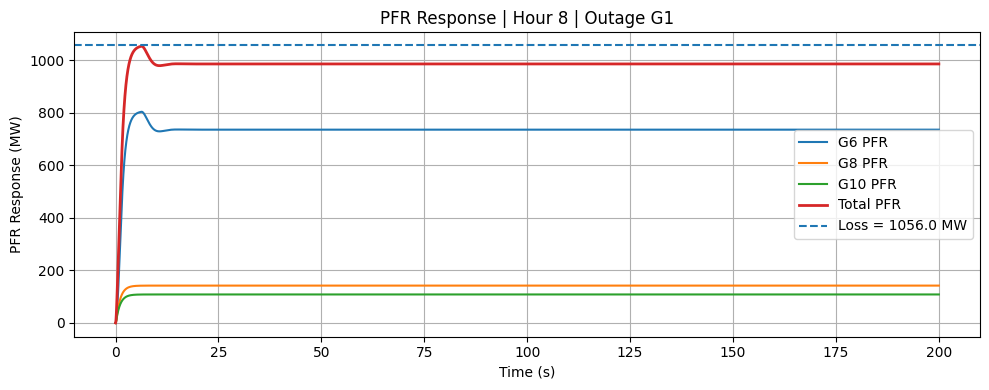

In [1064]:
# ============================================================
# 21. PLOT PFR RESPONSE
# ============================================================

plt.figure(figsize=(10, 4))

for g in freq_result["pfr_units"]:
    plt.plot(
        freq_result["time"],
        freq_result["pfr_history"][g],
        label=f"{g} PFR"
    )

plt.plot(
    freq_result["time"],
    freq_result["total_pfr_history"],
    linewidth=2,
    label="Total PFR"
)

plt.axhline(
    freq_result["loss"],
    linestyle="--",
    label=f"Loss = {freq_result['loss']:.1f} MW"
)

plt.xlabel("Time (s)")
plt.ylabel("PFR Response (MW)")
plt.title(f"PFR Response | Hour {t_uc} | Outage {freq_result['outage_g']}")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

22-Rekap Frekuensi Semua Jam

In [1065]:
# ============================================================
# 22. ALL-HOUR FREQUENCY SUMMARY
# ============================================================
# Bagian ini menjalankan simulasi frekuensi untuk semua jam.
# Hasilnya dipakai untuk melihat jam mana yang paling kritis.

summary = []

for th in list(model.T):
    fr = simulate_frequency_response(
        model=model,
        t_uc=th,
        f0=f0,
        D_frac=D_frac,
        sim_time=sim_time,
        dt=dt
    )

    total_reserve = sum(value(model.R[g, th]) for g in model.G)
    total_pfr = sum(value(model.R_pfr[g, th]) for g in model.G)
    net_deficit = fr["loss"] - total_pfr
    pfr_ratio = total_pfr / fr["loss"] if fr["loss"] > 0 else 0

    summary.append([
        th,
        fr["outage_g"],
        round(fr["loss"], 2),
        round(total_reserve, 2),
        round(total_pfr, 2),
        round(net_deficit, 2),
        round(pfr_ratio * 100, 2),
        round(fr["nadir"], 4),
        round(fr["qss"], 4)
    ])

df_freq_summary = pd.DataFrame(summary, columns=[
    "t",
    "Unit Trip",
    "Ploss (MW)",
    "Total Reserve (MW)",
    "Total PFR (MW)",
    "Net Deficit (MW)",
    "PFR Ratio (%)",
    "f_nadir (Hz)",
    "f_steady (Hz)"
])

print("\n========== FREQUENCY ALL-HOUR SUMMARY ==========")
print(df_freq_summary.to_string(index=False))


========== FREQUENCY ALL-HOUR SUMMARY ==========
 t Unit Trip  Ploss (MW)  Total Reserve (MW)  Total PFR (MW)  Net Deficit (MW)  PFR Ratio (%)  f_nadir (Hz)  f_steady (Hz)
 1        G1      958.91              958.91             0.0            958.91            0.0       48.0344        48.5239
 2        G1      932.66              932.66             0.0            932.66            0.0       48.0922        48.5770
 3        G1      890.68              890.68             0.0            890.68            0.0       48.1843        48.6622
 4        G3      870.00              870.00             0.0            870.00            0.0       48.3319        48.7032
 5        G1      870.00              870.00             0.0            870.00            0.0       48.2473        48.7032
 6        G1      951.84              951.84             0.0            951.84            0.0       48.0500        48.5382
 7        G1      996.21              996.21             0.0            996.21           

23-Grafik Ringkasan Frekuensi

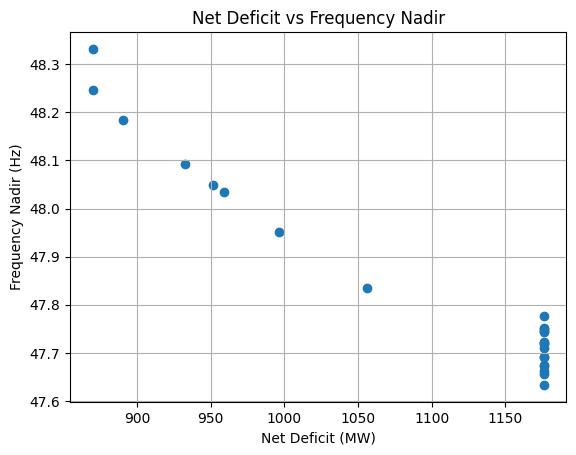

In [1066]:
# ============================================================
# 23. FREQUENCY SUMMARY PLOTS
# ============================================================

# Net deficit vs frequency nadir

plt.figure()

plt.scatter(
    df_freq_summary["Net Deficit (MW)"],
    df_freq_summary["f_nadir (Hz)"]
)

plt.xlabel("Net Deficit (MW)")
plt.ylabel("Frequency Nadir (Hz)")
plt.title("Net Deficit vs Frequency Nadir")
plt.grid()
plt.show()

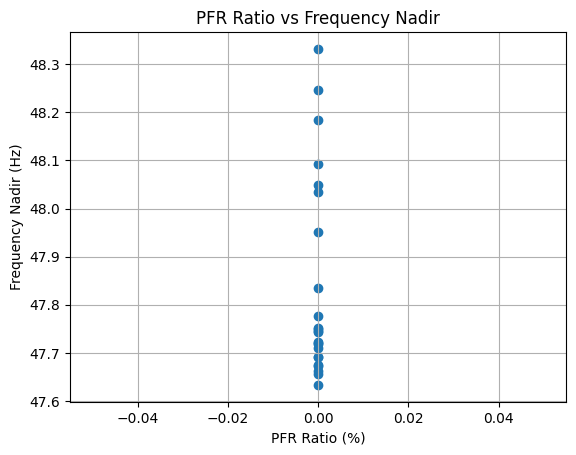

In [1067]:
# PFR ratio vs frequency nadir

plt.figure()

plt.scatter(
    df_freq_summary["PFR Ratio (%)"],
    df_freq_summary["f_nadir (Hz)"]
)

plt.xlabel("PFR Ratio (%)")
plt.ylabel("Frequency Nadir (Hz)")
plt.title("PFR Ratio vs Frequency Nadir")
plt.grid()
plt.show()

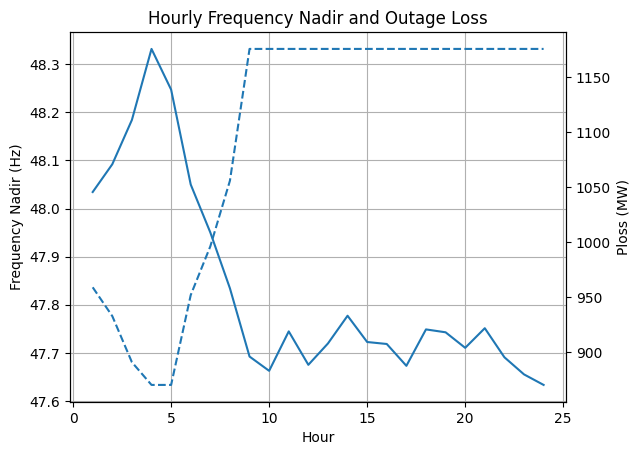

In [1068]:
# Trend nadir dan outage loss per jam

fig, ax1 = plt.subplots()

ax1.set_xlabel("Hour")
ax1.set_ylabel("Frequency Nadir (Hz)")
ax1.plot(df_freq_summary["t"], df_freq_summary["f_nadir (Hz)"])
ax1.grid()

ax2 = ax1.twinx()
ax2.set_ylabel("Ploss (MW)")
ax2.plot(df_freq_summary["t"], df_freq_summary["Ploss (MW)"], linestyle="--")

plt.title("Hourly Frequency Nadir and Outage Loss")
plt.show()

24-Plot UC Dispatch dan Status Unit

In [1069]:
# ============================================================
# 24. UC VISUALIZATION
# ============================================================

# Mapping nama unit agar legenda lebih mudah dibaca

name_map = {
    "G1": "PLTU 1",
    "G2": "PLTGU 1",
    "G3": "PLTU 2",
    "G4": "PLTUG 1",
    "G5": "PLTG 2",
    "G6": "PLTGU 2",
    "G7": "PLTGU 3",
    "G8": "PLTGU 4",
    "G9": "PLTU 3",
    "G10": "PLTU 4"
}

plot_labels = [name_map.get(g, g) for g in model.G]

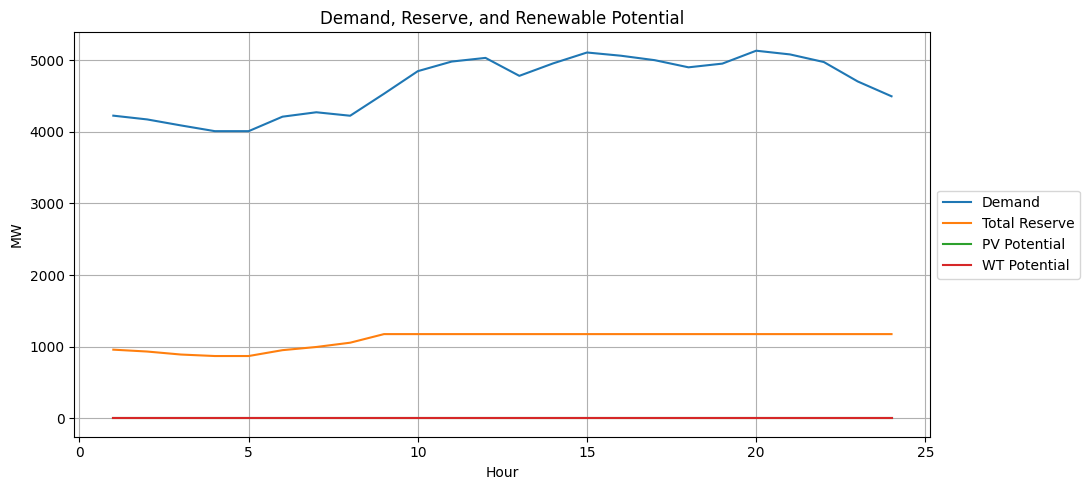

In [1070]:
# Demand, reserve, dan renewable potential

hours = list(model.T)

demand = [value(model.Demand[t]) for t in model.T]

total_reserve = [
    sum(value(model.R[g, t]) for g in model.G)
    for t in model.T
]

pv_potential = [
    sum(value(model.RenewPotential[g, t]) for g in model.G if Type[g] == "PV")
    for t in model.T
]

wt_potential = [
    sum(value(model.RenewPotential[g, t]) for g in model.G if Type[g] == "WT")
    for t in model.T
]

plt.figure(figsize=(11, 5))

plt.plot(hours, demand, label="Demand")
plt.plot(hours, total_reserve, label="Total Reserve")
plt.plot(hours, pv_potential, label="PV Potential")
plt.plot(hours, wt_potential, label="WT Potential")

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Demand, Reserve, and Renewable Potential")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.grid()
plt.show()

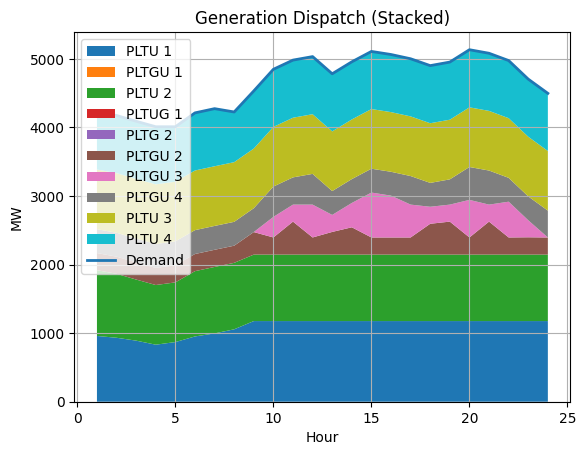

In [1071]:
# Dispatch per unit dalam bentuk stacked plot

gen_cols = [f"{g}_P" for g in model.G]

plt.figure()

plt.stackplot(
    df_hourly["Hour"],
    *[df_hourly[col] for col in gen_cols],
    labels=plot_labels
)

plt.plot(
    df_hourly["Hour"],
    df_hourly["Demand"],
    linewidth=2,
    label="Demand"
)

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Generation Dispatch (Stacked)")
plt.legend()
plt.grid()
plt.show()

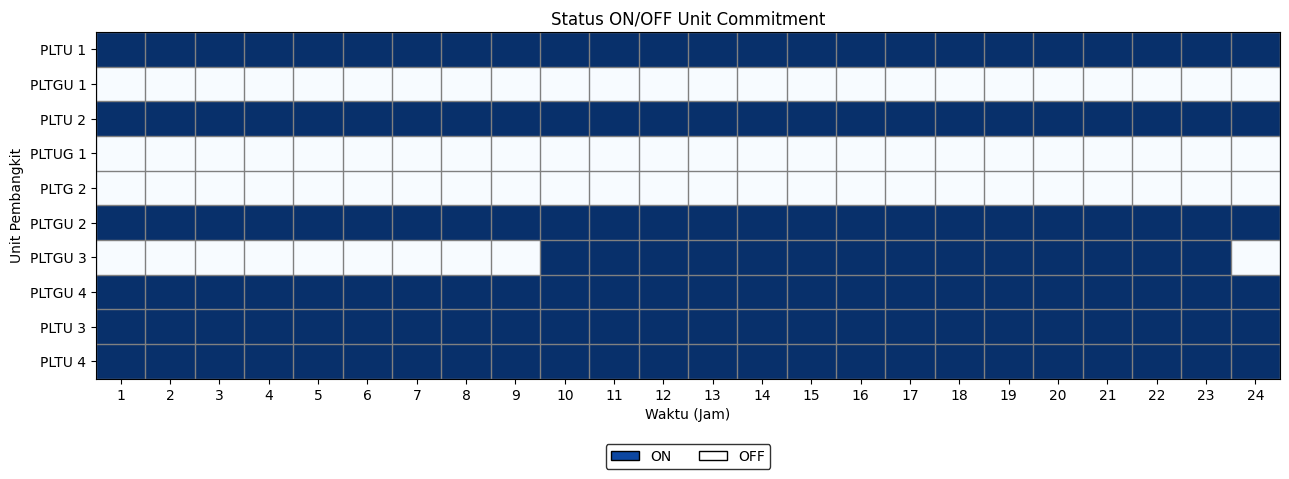

In [1072]:
# Status ON/OFF unit
gen_status_matrix = []

for g in model.G:
    gen_status_matrix.append([
        1 if value(model.u[g, t]) > 1e-4 else 0
        for t in model.T
    ])

matrix = np.array(gen_status_matrix)

# Nama unit
unit_labels = [name_map.get(g, g) for g in model.G]

plt.figure(figsize=(13, 5))

# Heatmap
plt.imshow(
    matrix,
    cmap="Blues",
    aspect="auto",
    interpolation="none",
    vmin=0,
    vmax=1
)

# =========================
# AXIS
# =========================
plt.xticks(
    ticks=np.arange(len(list(model.T))),
    labels=list(model.T)
)

plt.yticks(
    ticks=np.arange(len(list(model.G))),
    labels=unit_labels
)

# =========================
# GRID ANTAR KOTAK
# =========================
ax = plt.gca()

# Minor ticks di batas sel
ax.set_xticks(np.arange(-0.5, len(list(model.T)), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(list(model.G)), 1), minor=True)

# Grid hanya untuk minor
ax.grid(
    which="minor",
    color="gray",
    linestyle="-",
    linewidth=1
)

# Hilangkan tampilan minor tick
ax.tick_params(which="minor", bottom=False, left=False)

# =========================
# LABEL & TITLE
# =========================
plt.xlabel("Waktu (Jam)")
plt.ylabel("Unit Pembangkit")
plt.title("Status ON/OFF Unit Commitment")

# =========================
# LEGEND ON/OFF
# =========================
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#0d47a1", edgecolor="black", label="ON"),
    Patch(facecolor="white", edgecolor="black", label="OFF")
]

plt.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=2,
    frameon=True,
    edgecolor="black"
)

plt.tight_layout()

plt.show()